# IEEE 34 Node

In [1]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix

from unit_converter import UnitConverter
from topologia import FeederTopology

import fault
import fault1 
import fault2
# import fault3


import locator
import locator1
import locator1_2
import locator2
import locator3

from funcoes_plot import plot_erro

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('C:/Users/grei-luis-felipe/Documents/fault-location/tcc-luis-felipe')

In [3]:
DSS_FILE_REG_NEUTRAL = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_reg_neutral_tap.dss"
DSS_FILE_REG_SET = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_tap_setted.dss"
DSS_FILE_NO_REG = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_no_reg.dss"
DSS_FILE_NO_REG_PV = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_no_reg_pv.dss"
DSS_FILE_MI_POS_REG = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_mi_pos_regulator.dss"
DSS_FILE_TAP_SET = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_tap_setted.dss"



## Medida SE, com regulador tap neutro

Reguladores de tensão presente com tap em posição neutra


In [9]:
simulador = fault.FaultSimulator(str(DSS_FILE_REG_NEUTRAL), origin_bus='800', target_kv=14.37)

passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_REG_NEUTRAL), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df1 = localizador.df.copy()

Aplicando Filtro MI: 100%|██████████| 1962/1962 [00:00<00:00, 16146.37it/s]


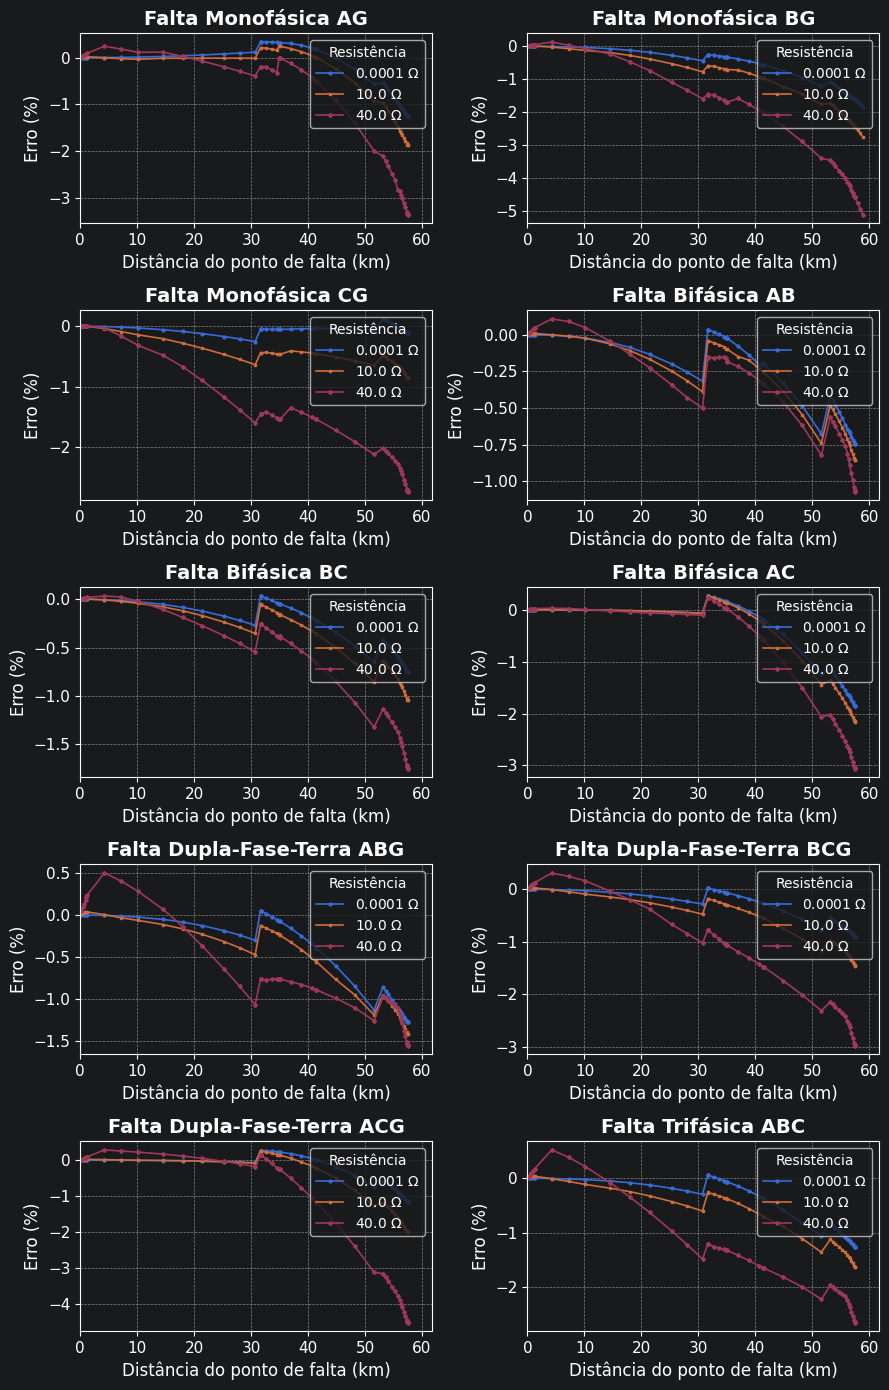

In [10]:
plot_erro(df1, simulador)

## Medida SE, com regulador tap setado

In [11]:
simulador = fault.FaultSimulator(str(DSS_FILE_REG_SET), origin_bus='800', target_kv=14.37)

passo_distancia = 0.30
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_REG_SET), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df2 = localizador.df.copy()

Aplicando Filtro MI: 100%|██████████| 1962/1962 [00:00<00:00, 16544.21it/s]


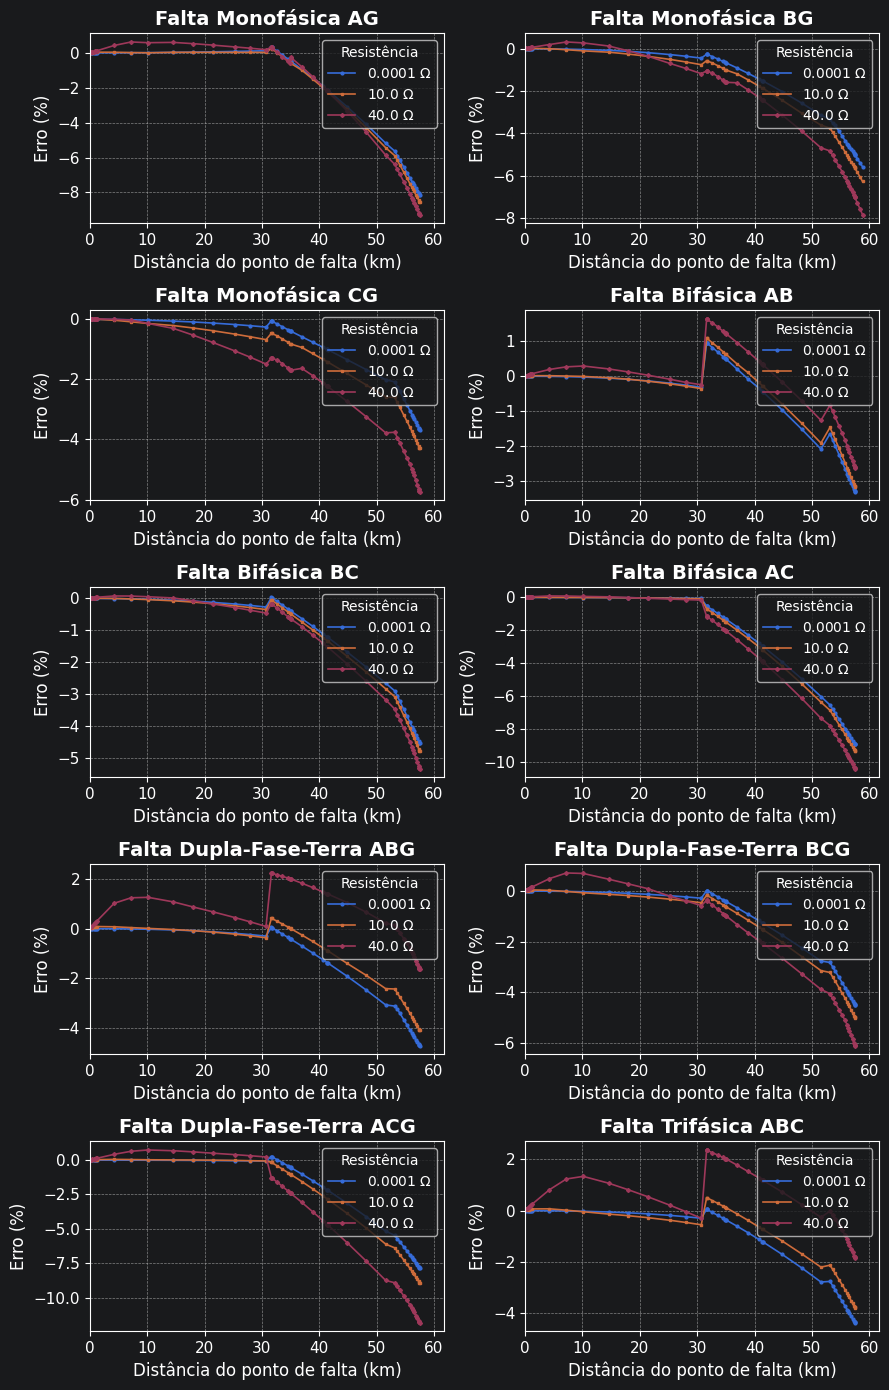

In [13]:
plot_erro(df2, simulador)

## Medida SE, sem regulador

In [14]:
simulador = fault.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='800', target_kv=14.37)

passo_distancia = 0.30
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df3 = localizador.df.copy()

Aplicando Filtro MI: 100%|██████████| 1962/1962 [00:00<00:00, 14971.70it/s]


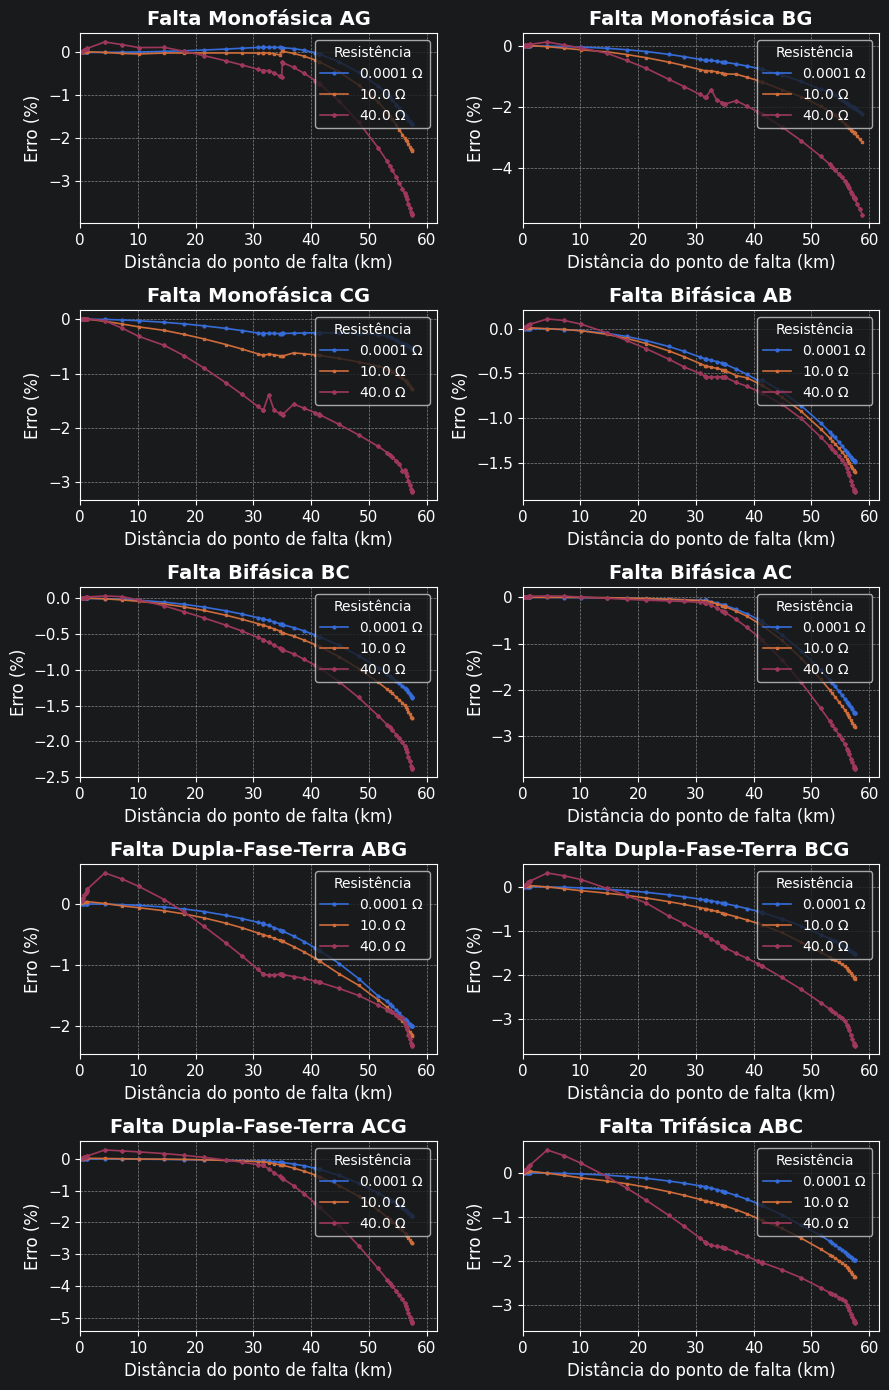

In [15]:
plot_erro(df3, simulador)

## Multiplas medidas, com regulador tap neutro

In [16]:
simulador = fault1.FaultSimulator(str(DSS_FILE_REG_NEUTRAL), origin_bus='800', target_kv=14.37)

passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_REG_NEUTRAL), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df4 = localizador.df.copy()


Localizando Faltas: 100%|██████████| 1962/1962 [03:11<00:00, 10.23it/s]


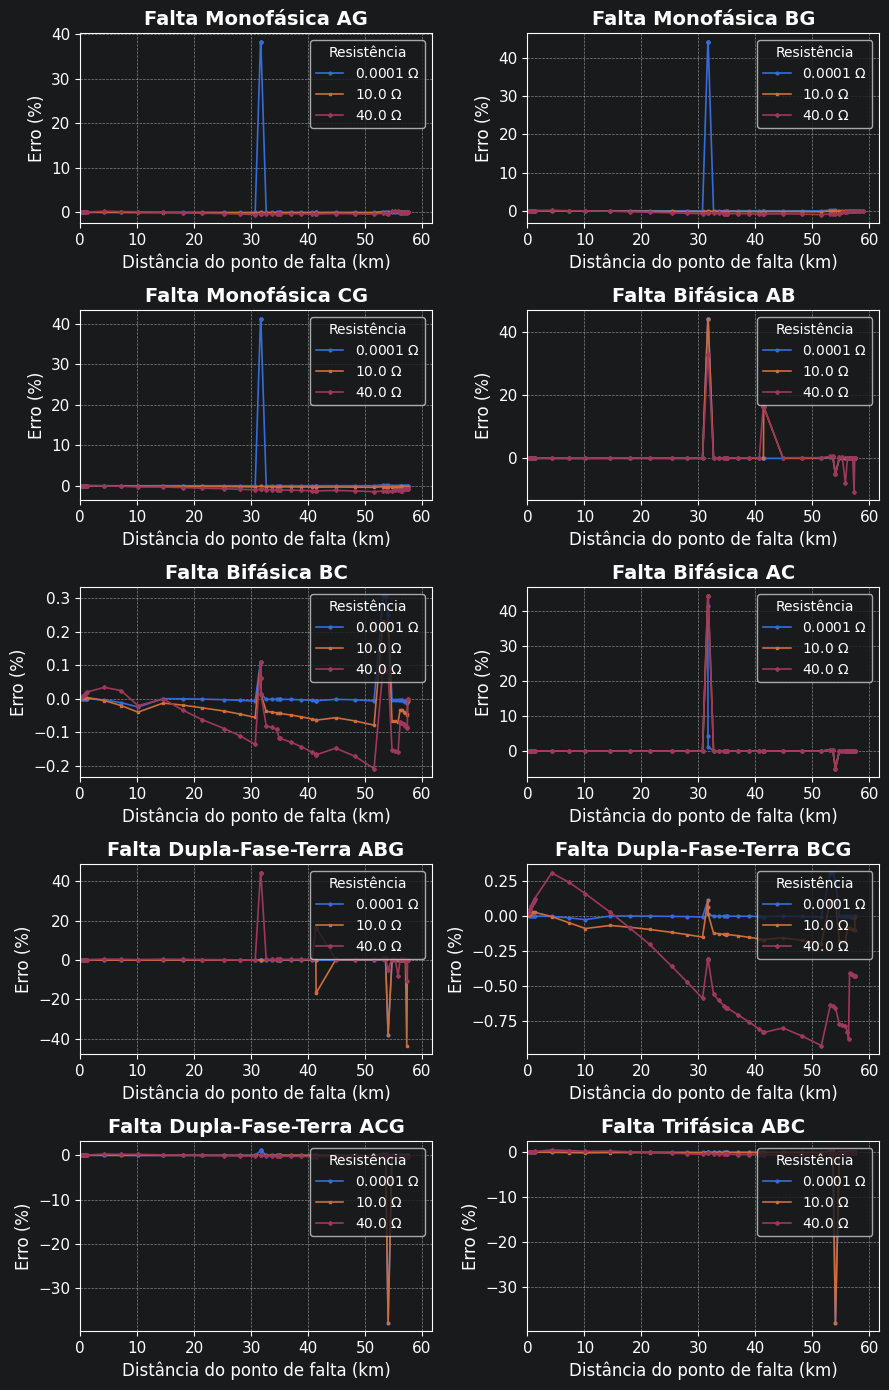

In [18]:
plot_erro(df4, simulador)

## Multiplas medidas, com regulador stado

In [19]:
simulador = fault1.FaultSimulator(str(DSS_FILE_REG_SET), origin_bus='800', target_kv=14.37)

passo_distancia = 0.30
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_REG_SET), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df5 = localizador.df.copy()


Localizando Faltas: 100%|██████████| 1962/1962 [03:00<00:00, 10.90it/s]


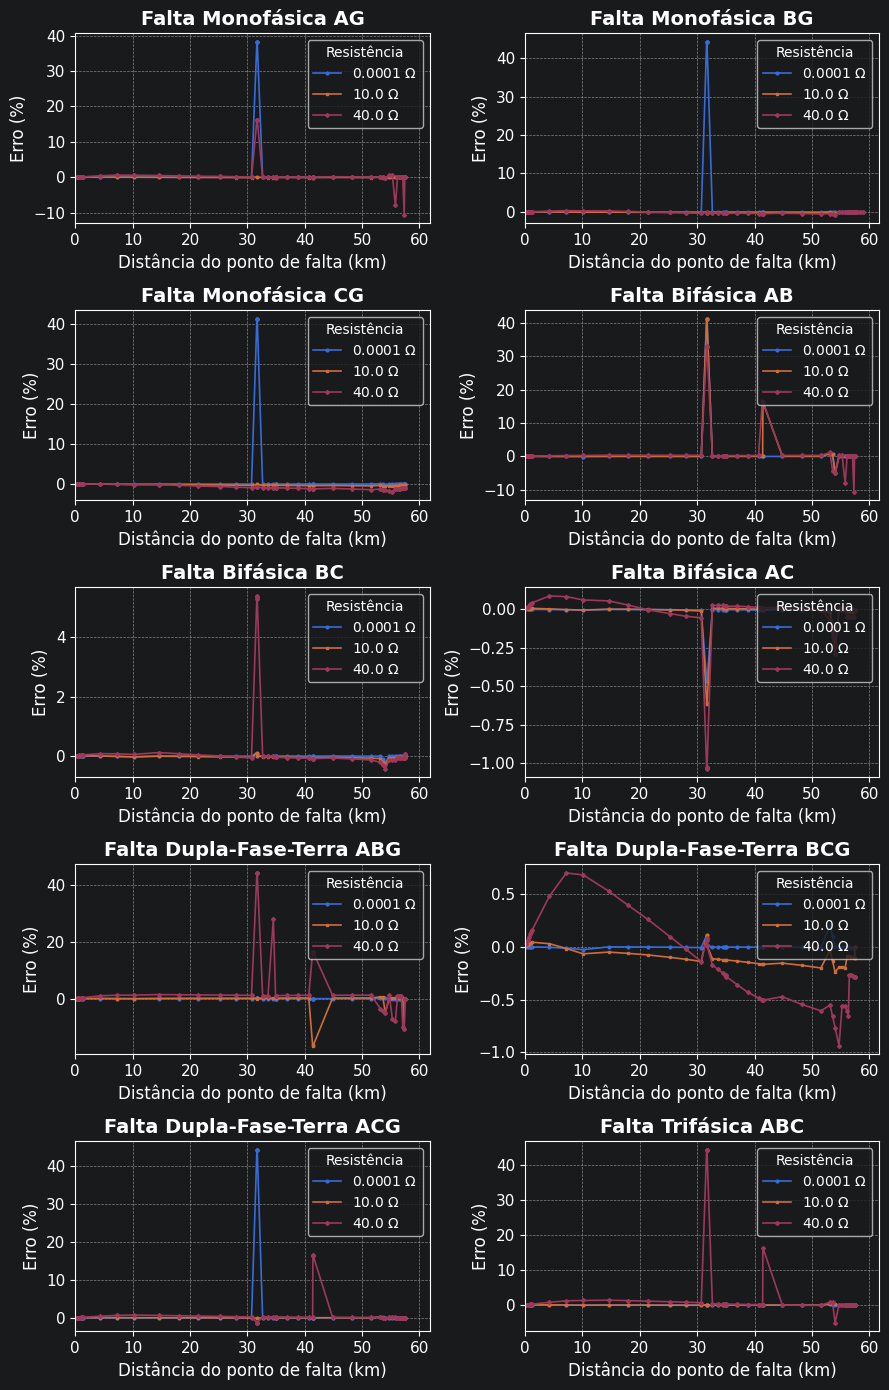

In [20]:
plot_erro(df5, simulador)

## Multiplas medidas, sem regulador

In [21]:
simulador = fault1.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='800', target_kv=14.37)

passo_distancia = 0.20
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1_2.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df6 = localizador.df.copy()


Localizando Faltas: 100%|██████████| 2616/2616 [03:15<00:00, 13.36it/s]


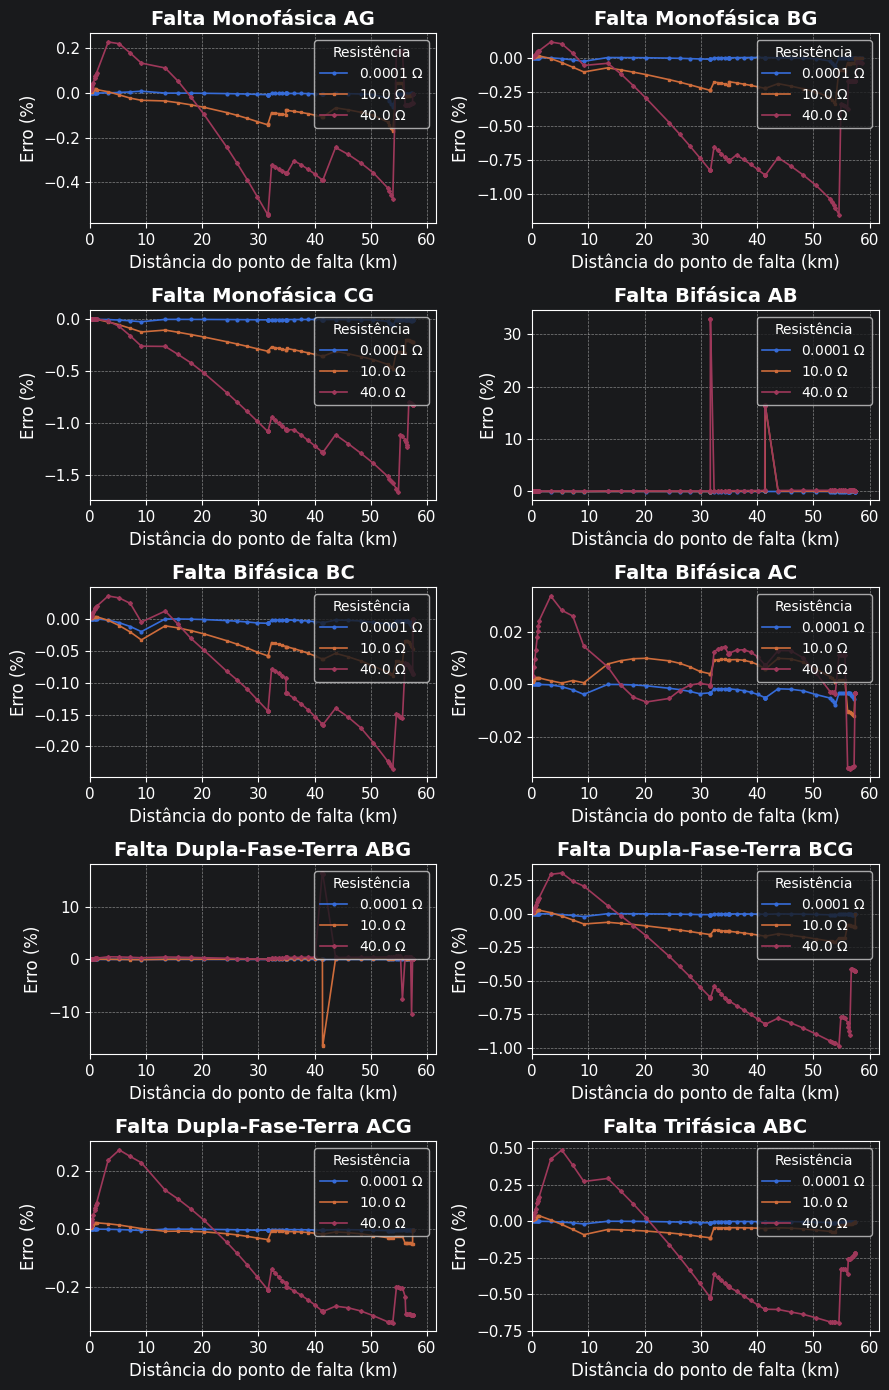

In [22]:
plot_erro(df6, simulador)

## Medida SE, sem regulador, com PV

In [ ]:
simulador = fault.FaultSimulator(str(DSS_FILE_NO_REG_PV), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_NO_REG_PV), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df3_1 = localizador.df.copy()


In [ ]:
plot_erro(df3_1, simulador)

## Multiplas medidas, sem regulador

In [ ]:
simulador = fault1.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df4 = localizador.df.copy()


In [ ]:
plot_erro(df4, simulador)

## Multiplas medidas, sem regulador, com pv

In [ ]:
simulador = fault1.FaultSimulator(str(DSS_FILE_NO_REG_PV), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_NO_REG_PV), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df4_1 = localizador.df.copy()


In [ ]:
plot_erro(df4_1, simulador)

## Multiplas medidas, com regulador, medida após regulador

In [ ]:
simulador = fault1.FaultSimulator(str(DSS_FILE_MI_POS_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_MI_POS_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df5 = localizador.df.copy()


In [ ]:
plot_erro(df5, simulador)

## Multiplas medidas, com regulador, versão 3

Nesta versão a impedância do transformador é incrementada

In [ ]:
simulador = fault2.FaultSimulator(str(DSS_FILE_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator2.FaultLocator(str(DSS_FILE_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df6 = localizador.df.copy()


In [ ]:
plot_erro(df6, simulador)

## Multiplas medidas, com regulador, versão 4

Nesta versão a impedância do transformador não é incrementada

In [ ]:
simulador = fault2.FaultSimulator(str(DSS_FILE_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator3.FaultLocator(str(DSS_FILE_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df7 = localizador.df.copy()


In [ ]:
plot_erro(df7, simulador)

## Multiplas medidas, com regulador, versão 5

Nesta versão a impedância do transformador é incrementada

In [ ]:
simulador = fault2.FaultSimulator(str(DSS_FILE_TAP_SET), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator3.FaultLocator(str(DSS_FILE_TAP_SET), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df8 = localizador.df.copy()


In [ ]:
plot_erro(df8, simulador)

## Comparação

In [ ]:
# Lista de dataframes e nomes para legenda
dfs = [
    # (df1, 'Caso 1'),
    # (df2, 'Caso 2'),
    # (df3, 'Caso 3'),
    # (df4, 'Caso 4'),
    # (df5, 'Caso 5'),
    (df6, 'Caso 6'),
    (df7, 'Caso 7'),
]

mapa_faltas = {
        'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
        'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
        'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
        'abc': 'Falta Trifásica ABC'
    }

# Marcadores, cores e estilos para diferenciar os dataframes
markers = ['o', 's', 'D', '^', 'v', 'P', 'X']
cores = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']
linestyles = ['-', '--', '-.', ':']

# --- Configuração Matplotlib (preservada) ---
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 9

# --- 1. Determinar coluna de resistência e resistências simuladas combinadas ---
def get_res_col(df):
    if df is None or df.empty:
        return None
    return 'r_f' if 'r_f' in df.columns else ('r' if 'r' in df.columns else None)

# Coletar todas as resistências únicas entre os dataframes (mantendo ordem)
res_set = set()
for df, _ in dfs:
    col = get_res_col(df)
    if col:
        res_set.update(df[col].dropna().unique())
resistencias_simuladas = sorted(res_set)

# --- 2. Calcular limite X (km) usando todos os dataframes filtrando pelo ramal principal ---
# Concatena temporariamente as colunas 'linha_faltosa' e 'distancia' quando existirem
distancias = []
for df, _ in dfs:
    if df is None or df.empty:
        continue
    if 'linha_faltosa' in df.columns and 'distancia' in df.columns:
        mask = df['linha_faltosa'].isin(ramal_principal)
        if mask.any():
            maxd = df.loc[mask, 'distancia'].max()
            if pd.notna(maxd):
                distancias.append(maxd)

if distancias:
    limite_x_km = (max(distancias) / 1000.0) * 1.05
else:
    limite_x_km = None  # será tratado mais abaixo

# --- 3. Criação do grid de subplots (5x2) ---
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))
axes = axes.flatten()

# Itera sobre cada tipo de falta e cria o subplot correspondente
for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    # Verifica se há dados para este tipo de falta em qualquer dataframe
    any_data = False

    for idx_df, (df, df_name) in enumerate(dfs):
        if df is None or df.empty:
            continue
        if 'tipo' not in df.columns or 'linha_faltosa' not in df.columns or 'distancia' not in df.columns or 'erro_percentual' not in df.columns:
            continue

        # Filtra por tipo de falta e ramal principal
        df_tipo = df[(df['tipo'] == tipo_falta) & (df['linha_faltosa'].isin(ramal_principal))].copy()
        if df_tipo.empty:
            continue

        any_data = True
        col_res = get_res_col(df)
        if col_res is None:
            continue

        # Para cada resistência simulada, plota a curva correspondente (se existir)
        for i, res in enumerate(resistencias_simuladas):
            df_plot = df_tipo[df_tipo[col_res] == res].copy()
            if df_plot.empty:
                continue

            # Converter metros para quilômetros e ordenar
            df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
            df_plot = df_plot.sort_values(by='distancia_km')

            # Estilo: cor por dataframe, marcador por resistência index
            cor = cores[idx_df % len(cores)]
            ls = linestyles[idx_df % len(linestyles)]
            marker_estilo = markers[i % len(markers)]

            # Label com resistência e origem do dataframe
            label = f'{res} Ω — {df_name}'

            ax.plot(
                df_plot['distancia_km'],
                df_plot['erro_percentual'],
                color=cor,
                linestyle=ls,
                marker=marker_estilo,
                markersize=3,
                linewidth=1.2,
                label=label
            )

    if not any_data:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)", fontweight='bold')
        ax.axis('off')
        continue

    # Configurações do subplot
    ax.set_title(titulo_grafico, fontweight='bold')
    if limite_x_km is not None:
        ax.set_xlim(0, limite_x_km)
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    ax.grid(True, linestyle="--", alpha=0.7)

    # Ajusta legenda: se houver muitas entradas, usa bbox_to_anchor para não sobrepor
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) <= 6:
        ax.legend(title="Resistência — Fonte", loc='upper right')
    else:
        ax.legend(title="Resistência — Fonte", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Remove eixos extras caso mapa_faltas tenha menos de 10 itens
for ax in axes[len(mapa_faltas):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
